# Evaluating predicted splice-usage trajectories against the reference clustering

Each **predicted** developmental trajectory is placed into the *fixed* clustering of the
**observed (true)** trajectories — never re-clustered independently — and scored on whether it
lands in the same cluster / shape as its observed counterpart.

Pipeline (all in `alphagenome_pytorch.clustering`, driven by `scripts/cluster_predictions.py`):
1. Load the true-trajectory clustering as a reference and take its per-cluster **centroids**.
2. GP-smooth the predicted **and** observed trajectories with the *identical* transform
   (same kernel, true reads as weights) so they live in the reference feature space.
3. Assign each to the nearest centroid → `pred_shape` / `obs_shape` (+ cluster ids).
4. Compare **pred vs obs** (apples-to-apples, same pipeline) and **pred vs the canonical Ward
   reference** labels.

**Shape labels use a hierarchical dynamic/direction scheme** (`classify_dynamic_direction`,
`DYNAMIC_SHAPE_ORDER`): 
- level 1 is dynamic-or-not, decided by the same exc5 excursion gate used
by the training-time trajectory loss and during evaluation `trajectory-corr`; 
- level 2, for dynamic trajectories only, is plain direction -
`up` / `down` / a mid-trajectory reversal (`up-down` / `down-up`). 

There are therefore only 5 labels in total, replacing an earlier 14-way scheme 
(early/mid/late timing x high/low baseline subdivisions) that turned out to be 
far stricter than the underlying prediction quality.

## Setup

In [1]:
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Hierarchical dynamic/direction labeling (see clustering.py): first dynamic-or-not
# via the same exc5 excursion gate used by training/evaluate_splice.py, then for
# dynamic trajectories only, plain direction. Only 5 labels -- no separate "fine"
# vs "broad" granularity anymore, since this scheme has nothing finer to reduce.
from alphagenome_pytorch.clustering import DYNAMIC_SHAPE_ORDER as SHAPE_ORDER, DYNAMIC_SHAPE_COLORS as SHAPE_COLORS

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
SPECIES_LIST = ["human", "mouse"]  # all species with prediction-cluster results
TISSUE_LIST  = ["Brain", "Cerebellum", "Liver", "Testis"]      # all tissues with prediction-cluster results
SPECIES = SPECIES_LIST[0]             # species used for the single-example walk-through (sections 1, 5-7)
TISSUE  = TISSUE_LIST[0]              # tissue used for the single-example walk-through (sections 1, 5-7)
SPLIT   = "test"

HOME   = os.path.expanduser("~")
ROOT   = os.path.join(HOME, "sds", "sd17d003", "Anamaria")
MODEL  = "lora_64_emb_traj_hqmrboc"
BASE   = os.path.join(ROOT, "alphagenome_genomicsxai", MODEL, "preds_intersect_protein_coding")
REF_DIR    = os.path.join(ROOT, "gp_splice_usage")                                   # true-clustering
PREDS_DIR  = BASE                                                                     # predicted-usage root
                                                                                       # (<PREDS_DIR>/<species>/usage_<species>.parquet)
USAGE_TMPL = os.path.join(ROOT, "alphagenome_genomicsxai", "data",
                          "combined_usage_data_{species}.parquet")                   # true reads/strand

def prefix(sp=None, tis=None, split=None):
    sp, tis, split = sp or SPECIES, tis or TISSUE, split or SPLIT
    return f"{sp}_{tis.replace(' ', '_')}_{split}"

def preds_parquet_path(sp=None):
    return os.path.join(PREDS_DIR, sp or SPECIES, f"usage_{sp or SPECIES}.parquet")

def out_dir(sp=None, tis=None):
    sp, tis = sp or SPECIES, tis or TISSUE
    return os.path.join(BASE, sp, "pred_gp_splice_usage", tis.replace(" ", "_"))

def pred_clusters_path(sp=None, tis=None, split=None):
    return os.path.join(out_dir(sp, tis), f"{prefix(sp, tis, split)}_prediction_clusters.parquet")

OUT_DIR       = out_dir()                 # used by the single-example walk-through (plots saved here)
PRED_CLUSTERS = pred_clusters_path()
print("walk-through species/tissue:", SPECIES, "/", TISSUE)
print("annotated parquet:", PRED_CLUSTERS)
print("exists:", os.path.exists(PRED_CLUSTERS))

walk-through species/tissue: human / Brain
annotated parquet: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_64_emb_traj_hqmrboc/preds_intersect_protein_coding/human/pred_gp_splice_usage/Brain/human_Brain_test_prediction_clusters.parquet
exists: True


## 1 — Load the annotated prediction clusters

If the parquet is missing, run `scripts/cluster_predictions.py` for this species/tissue (GP
smoothing of both trajectories — a few minutes per tissue).

In [3]:
if not os.path.exists(PRED_CLUSTERS):
    print("Not found - computing via scripts/cluster_predictions.py ...")
    subprocess.run([
        "python", "../../scripts/cluster_predictions.py",
        "--species", SPECIES, "--tissue", TISSUE, "--split", SPLIT,
        "--ref-dir", REF_DIR, "--output", OUT_DIR,
        "--preds-dir", PREDS_DIR, "--usage-template", USAGE_TMPL,
    ], check=True)

In [4]:
# Shared utilities for trajectory magnitude (Section 2b) and RMSE-adjusted shape agreement
# (used throughout this notebook -- Sections 2, 4, 5, 8, 9; see the note under Section 2
# below). Defined here, before Section 2, so its headline numbers already use it. Numpy ports
# of evaluate_splice.py's compute_trajectory_magnitude / _trajectory_excursion_np /
# _amplitude_r2 / _nanmedian_torch_style, kept notebook-local (rather than importing from
# scripts/) to stay self-contained like the rest of this notebook. Mirrors that script exactly,
# including using torch's nanmedian convention (lower-of-two-middle for an even count, not
# numpy's average) -- not cosmetic, it can flip which side of EXC_FLOOR a borderline trajectory
# falls on, so eligibility wouldn't match training/evaluation otherwise.
MIN_TP, EXC_FLOOR, MEDIAN_WIN = 3, 0.10, 5


def _nanmedian_torch_style(windows):
    sorted_w = np.sort(windows, axis=-1)  # NaNs sort to the end (ascending)
    n_valid = np.sum(~np.isnan(windows), axis=-1)
    idx = np.clip((n_valid - 1) // 2, 0, windows.shape[-1] - 1)
    return np.take_along_axis(sorted_w, idx[..., None], axis=-1).squeeze(-1)


def _masked_median_filter(x, mask, win=5):
    """Median-filter x along axis -1, ignoring positions where mask is False (an isolated
    1-2 point noisy timepoint is outvoted by its valid neighbors, not diluted)."""
    N, T = x.shape
    win = max(1, min(win, T if T % 2 == 1 else T - 1))
    half = win // 2
    x_nan = np.where(mask, x, np.nan)
    x_pad = np.pad(x_nan, ((0, 0), (half, half)), mode="constant", constant_values=np.nan)
    windows = np.lib.stride_tricks.sliding_window_view(x_pad, win, axis=1)
    n_valid = np.sum(~np.isnan(windows), axis=-1)
    filt = _nanmedian_torch_style(windows)
    return np.where(n_valid > 0, filt, 0.0)


def _trajectory_excursion(dt, mask, win=5):
    """Max deviation from baseline of the median-filtered, self-recentered trajectory -- the
    masked/sparse-observation counterpart of clustering.trajectory_excursion (which assumes a
    dense, fully-observed curve like a GP-smoothed feature vector)."""
    dt_filt = _masked_median_filter(dt, mask, win=win)
    denom = np.clip(mask.sum(axis=1), 1, None).astype(np.float64)
    mu_filt = (dt_filt * mask).sum(axis=1) / denom
    dt_filt_c = dt_filt - mu_filt[:, None]
    big = np.finfo(np.float64).max / 4
    exc_max = np.where(mask, dt_filt_c, -big).max(axis=1)
    exc_min = np.where(mask, dt_filt_c, big).min(axis=1)
    return np.maximum(exc_max, -exc_min)


def _amplitude_r2(true_amp, pred_amp):
    """Unrefit R^2 between true/predicted excursion magnitude -- see Section 2b below for why
    this, not Pearson r, is used."""
    if true_amp.size < 2:
        return float("nan")
    ss_tot = np.sum((true_amp - true_amp.mean()) ** 2)
    if ss_tot < 1e-12:
        return float("nan")
    ss_res = np.sum((pred_amp - true_amp) ** 2)
    return float(1.0 - ss_res / ss_tot)


def _traj_wide(species, tissue, sites=None):
    """Wide (site x timepoint) true/pred/mask matrices for every site with data in the raw
    predicted-usage parquet -- vectorized counterpart of `_traj()` (Section 5) for computing
    summary statistics across many sites at once instead of one at a time. `sites`, if given,
    restricts to a set of (chrom, pos) pairs (e.g. the site population in `df`)."""
    p = pd.read_parquet(preds_parquet_path(species),
                        columns=["Chromosome", "Position", "Tissue", "Timepoint",
                                 "SSE_true", "SSE_pred"])
    p = p[p["Tissue"] == tissue].copy()
    p["Chromosome"] = p["Chromosome"].astype(str)
    if sites is not None:
        site_set = {(str(c), int(pos)) for c, pos in sites}
        p = p[[(c, pos) in site_set for c, pos in zip(p["Chromosome"], p["Position"])]]
    p["site"] = list(zip(p["Chromosome"], p["Position"]))

    true_wide = p.pivot_table(index="site", columns="Timepoint", values="SSE_true")
    pred_wide = p.pivot_table(index="site", columns="Timepoint", values="SSE_pred")
    mask = ~true_wide.isna()
    return (true_wide.index.to_numpy(),
            true_wide.fillna(0.0).to_numpy(), pred_wide.fillna(0.0).to_numpy(), mask.to_numpy())


def _site_rmse_all(species, tissue, sites=None):
    """Per-site RMSE for every site at once (via `_traj_wide`) -- literal residual
    (true - pred) at each observed timepoint, no eligibility gate (well-defined for any site
    with >= 2 observed timepoints, not just the exc5-dynamic subset used in Section 2b).
    Feeds `load_annotated`'s shape-agreement adjustment below."""
    site_keys, true_mat, pred_mat, mask = _traj_wide(species, tissue, sites=sites)
    n_obs = mask.sum(axis=1)
    denom = np.clip(n_obs, 1, None).astype(np.float64)
    residual = np.where(mask, true_mat - pred_mat, 0.0)
    site_mse = (residual ** 2 * mask).sum(axis=1) / denom
    rmse = np.sqrt(site_mse)
    rmse[n_obs < 2] = np.nan
    # Explicit dtypes -- when `site_keys` is empty (a combo with zero sites, e.g. an empty
    # prediction-cluster parquet), pd.DataFrame({"Chromosome": []}) would otherwise default to
    # float64 instead of object/str, breaking load_annotated's merge against d["Chromosome"].
    out = pd.DataFrame({
        "Chromosome": [str(k[0]) for k in site_keys],
        "Position": [int(k[1]) for k in site_keys],
        "site_rmse": rmse,
    })
    out["Chromosome"] = out["Chromosome"].astype(str)
    out["Position"] = out["Position"].astype(np.int64)
    return out


def load_annotated(species, tissue, split=SPLIT):
    """Load one species/tissue's prediction-cluster parquet and add the RMSE-adjusted shape
    agreement columns used throughout this notebook (Sections 2, 4, 5, 8, 9).
    `classify_dynamic_direction`'s dynamic-or-not gate is a hard, margin-free threshold on
    excursion size, so a predicted trajectory that tracks the true one closely pointwise can
    still land a categorical `same_shape` / `same_shape_ref` mismatch (e.g. `non_dynamic` vs
    `up`) purely because its smoothed excursion sits just below EXC_FLOOR instead of just
    above -- a boundary artifact, not a real directional miss (see Section 5's per-example
    walkthrough, where these are flagged "(rescued)"). `same_shape_adj` / `same_shape_ref_adj`
    count those cases (`site_rmse < EXC_FLOOR`) as agreeing too."""
    d = pd.read_parquet(pred_clusters_path(species, tissue, split))
    rmse = _site_rmse_all(species, tissue, sites=list(zip(d["Chromosome"], d["Position"])))
    d = d.merge(rmse, on=["Chromosome", "Position"], how="left")
    rmse_ok = d["site_rmse"] < EXC_FLOOR
    d["same_shape_adj"] = d["same_shape"] | rmse_ok
    d["same_shape_ref_adj"] = d["same_shape_ref"] | rmse_ok
    return d


df = load_annotated(SPECIES, TISSUE)
n_rescued = int((~df["same_shape"] & (df["site_rmse"] < EXC_FLOOR)).sum())
print(f"{SPECIES}/{TISSUE}: {len(df):,} sites  |  columns: {list(df.columns)}")
print(f"  same_shape rescued by RMSE < {EXC_FLOOR}: {n_rescued:,} ({n_rescued / len(df):.1%} of all sites)")
df.head()

human/Brain: 15,544 sites  |  columns: ['Chromosome', 'Position', 'Strand', 'ref_cluster', 'ref_shape', 'obs_cluster', 'obs_shape', 'pred_cluster', 'pred_shape', 'same_cluster', 'same_shape', 'same_cluster_ref', 'same_shape_ref', 'pred_centroid_dist', 'obs_centroid_dist', 'n_obs', 'site_rmse', 'same_shape_adj', 'same_shape_ref_adj']
  same_shape rescued by RMSE < 0.1: 266 (1.7% of all sites)


,Chromosome,Position,Strand,ref_cluster,ref_shape,obs_cluster,obs_shape,pred_cluster,pred_shape,same_cluster,same_shape,same_cluster_ref,same_shape_ref,pred_centroid_dist,obs_centroid_dist,n_obs,site_rmse,same_shape_adj,same_shape_ref_adj
0,1,1535506,-,39,non_dynamic,39,non_dynamic,26,non_dynamic,False,True,False,True,0.100545,0.145337,15,0.093682,True,True
1,1,1535588,-,34,non_dynamic,39,non_dynamic,39,non_dynamic,True,True,False,True,0.153120,0.130018,15,0.072976,True,True
2,1,1535796,-,39,non_dynamic,27,up,26,non_dynamic,False,False,False,True,0.151253,0.159650,15,0.114346,False,True
3,1,1539683,-,27,up,27,up,27,up,True,True,True,True,0.156677,0.169956,15,0.062515,True,True
4,1,1539789,-,25,up,25,up,25,up,True,True,True,True,0.198332,0.349961,15,0.110713,True,True


## 2 — Headline agreement

- **pred vs obs** — both trajectories through the identical GP + nearest-centroid pipeline
  (isolates prediction error from classifier noise). This is the metric to use downstream.
- **pred vs ref** — predicted vs the canonical Ward reference label of the observed site.
- **obs vs ref** — re-smoothed observed vs Ward reference = the pipeline's reproducibility
  ceiling.

**Shape agreement (`pred vs obs` / `pred vs ref`) is RMSE-adjusted**: a categorical mismatch
counts as agreeing anyway when that site's `site_rmse < EXC_FLOOR` (0.10) — see Section 2b for
what `site_rmse` is, and the note above Section 5 for why (a hard, margin-free classification
threshold can flip on a well-tracked prediction). `obs vs ref` and the cluster-level numbers are
unaffected — they aren't about prediction quality.

In [5]:
def frac(mask): return float(np.mean(mask)) if len(mask) else float("nan")

summary = pd.DataFrame({
    "shape": [frac(df["same_shape_adj"]), frac(df["same_shape_ref_adj"]),
              frac(df["obs_shape"] == df["ref_shape"])],
    "cluster": [frac(df["same_cluster"]), frac(df["same_cluster_ref"]),
                frac(df["obs_cluster"] == df["ref_cluster"])],
}, index=["pred vs obs", "pred vs ref (Ward)", "obs vs ref (ceiling)"]).round(3)
print(f"{SPECIES}/{TISSUE}  —  {len(df):,} sites")
display(summary)

human/Brain  —  15,544 sites


,shape,cluster
pred vs obs,0.851,0.112
pred vs ref (Ward),0.863,0.079
obs vs ref (ceiling),0.942,0.515


Shape/cluster agreement for every `(species, tissue)` combination in `SPECIES_LIST × TISSUE_LIST`
that has a prediction-cluster parquet.

In [6]:
rows = []
for sp in SPECIES_LIST:
    for tis in TISSUE_LIST:
        path = pred_clusters_path(sp, tis, SPLIT)
        if not os.path.exists(path):
            continue
        d = load_annotated(sp, tis, SPLIT)
        rows.append(dict(
            species=sp, tissue=tis, n_sites=len(d),
            shape_pred_vs_obs=round(d["same_shape_adj"].mean(), 3),
            shape_pred_vs_ref=round(d["same_shape_ref_adj"].mean(), 3),
            shape_obs_vs_ref=round((d["obs_shape"] == d["ref_shape"]).mean(), 3),   # ceiling
            cluster_pred_vs_obs=round(d["same_cluster"].mean(), 3),
        ))
species_tissue_summary = pd.DataFrame(rows).set_index(["species", "tissue"])
display(species_tissue_summary)

n_sites  shape_pred_vs_obs  shape_pred_vs_ref  \
species tissue                                                      
human   Brain         15544              0.851              0.863   
        Cerebellum    13391              0.959              0.963   
        Liver         10177              0.938              0.944   
        Testis        16008              0.898              0.901   
mouse   Brain         11086              0.921              0.924   
        Cerebellum    11151              0.938              0.941   
        Liver          9254              0.938              0.938   
        Testis        10950              0.917              0.923   

                    shape_obs_vs_ref  cluster_pred_vs_obs  
species tissue                                             
human   Brain                  0.942                0.112  
        Cerebellum             0.968                0.139  
        Liver                  0.979                0.091  
        Testis                 0.965                0.127  
mouse   Brain                  0.966                0.102  
        Cerebellum             0.979                0.082  
        Liver                  0.964                0.090  
        Testis                 0.978                0.068

## 2b — Trajectory magnitude: R² and RMSE

Section 2's shape/cluster agreement only measures **direction** — a model that predicts the
right shape but at half the true amplitude scores perfectly there. These three metrics measure
**magnitude** instead, exactly matching the "Trajectory magnitude" section of
`plot_model_comparison.py` / `evaluate_splice.py --trajectory-corr`:

- **`amplitude_r2`** — unrefit R² (*not* Pearson r²) between true and predicted excursion
  size, **pooled across many sites**, scoring only each site's single peak-excursion point
  (1 = perfect, 0 = no better than predicting the mean, negative = worse than the mean).
  Deliberately not Pearson r: r is scale-invariant, so a model that uniformly compresses every
  amplitude by e.g. 2x scores a perfect r=1.0 despite being systematically wrong on magnitude —
  R² penalizes that.
- **`trajectory_r2`** — the same R² formula as `amplitude_r2`, but scored across *every*
  observed timepoint of every eligible trajectory instead of collapsing each site down to its
  single peak-excursion point — so it won't look fine when the model is wrong in the middle of
  a trajectory (or vice versa). Same scale/interpretation as `amplitude_r2`.
  Both R² variants are undefined for a single site (need a population to have a variance to
  normalize against), so neither appears in Section 5's per-site examples.
- **`rmse`** / **`trajectory_r2`**'s residual — literal, uncentered `true - pred` at each
  observed timepoint (sqrt'd into raw usage-fraction units for `rmse`). Unlike `amplitude_r2`
  (which only ever looks at each site's self-recentered peak excursion), this also reflects any
  absolute level/bias error, not just magnitude/shape. `rmse` is well-defined per
  **individual** site too — used in Section 5 below.

All three restricted to the same exc5-filtered "genuinely dynamic" subset as training/evaluation
(≥ `MIN_TP` observed timepoints AND median-filtered excursion > `EXC_FLOOR`), and all three still
weight large absolute excursions more than small ones, same as the `delta_mse` training loss.

In [7]:
def compute_magnitude_metrics(species, tissue, sites=None,
                               min_tp=MIN_TP, exc_floor=EXC_FLOOR, median_win=MEDIAN_WIN):
    """Pooled amplitude_r2 + rmse for one species/tissue -- the single-tissue counterpart of
    evaluate_splice.py's compute_trajectory_magnitude (no per-tissue grouping loop needed since
    everything here is already filtered to one tissue). Reuses _traj_wide / _trajectory_excursion
    / _amplitude_r2 from the utilities cell above (defined early so the RMSE-adjusted shape
    agreement in Section 2 could use them too)."""
    site_keys, true_mat, pred_mat, mask = _traj_wide(species, tissue, sites=sites)
    n_obs = mask.sum(axis=1)
    denom = np.clip(n_obs, 1, None).astype(np.float64)
    mu_t = (true_mat * mask).sum(axis=1) / denom
    mu_p = (pred_mat * mask).sum(axis=1) / denom
    dt = np.where(mask, true_mat - mu_t[:, None], 0.0)
    dp = np.where(mask, pred_mat - mu_p[:, None], 0.0)

    # Literal, uncentered residual (true - pred) at each observed timepoint -- unlike dt/dp
    # above (self-recentered purely to define "deviation from baseline" for the
    # excursion/amplitude_r2 computation below), rmse/trajectory_r2 measure how far off the raw
    # prediction is, including any absolute level/bias error, matching evaluate_splice.py.
    residual = np.where(mask, true_mat - pred_mat, 0.0)
    site_mse = (residual ** 2 * mask).sum(axis=1) / denom
    excursion_true = _trajectory_excursion(dt, mask, win=median_win)
    excursion_pred = _trajectory_excursion(dp, mask, win=median_win)
    eligible = (n_obs >= min_tp) & (excursion_true > exc_floor)

    rmse = float(np.sqrt(site_mse[eligible].mean())) if eligible.any() else float("nan")
    amp_r2 = _amplitude_r2(excursion_true[eligible], excursion_pred[eligible])

    # trajectory_r2: SS_res from the literal residual above (same numerator as rmse, so it
    # moves with rmse and also picks up level/bias error); SS_tot from dt (each trajectory's
    # own variance around its own mean, same baseline amplitude_r2 uses) -- scored across every
    # observed timepoint of every eligible trajectory instead of collapsing each site down to
    # its single peak-excursion point, catching errors in the middle of a trajectory that
    # amplitude_r2 (extremum-only) can miss. Mirrors evaluate_splice.py's
    # compute_trajectory_magnitude exactly.
    eligible_pt_mask = mask & eligible[:, None]
    tissue_dt_points = dt[eligible_pt_mask]
    tissue_residual_points = residual[eligible_pt_mask]
    ss_tot = float(np.sum(tissue_dt_points ** 2))
    traj_r2 = float(1.0 - np.sum(tissue_residual_points ** 2) / ss_tot) if ss_tot > 1e-12 else float("nan")

    return {
        "n_sites_total": int(len(site_keys)),
        "n_sites_eligible": int(eligible.sum()),
        "rmse": rmse,
        "amplitude_r2": amp_r2,
        "trajectory_r2": traj_r2,
    }


def _site_rmse(chrom, pos):
    """Single-site RMSE on the literal residual (true - pred) at each observed timepoint --
    unlike amplitude_r2/trajectory_r2 (need a population variance to normalize against), this
    is well-defined for one trajectory, so it's the metric shown per individual example in
    Section 5 below. See the utilities cell above for the vectorized `_site_rmse_all`
    counterpart used for the RMSE-adjusted shape agreement."""
    t, yt, yp = _traj(chrom, pos)
    if len(t) < 2:
        return float("nan")
    residual = yt - yp
    return float(np.sqrt(np.mean(residual ** 2)))


mag_metrics = compute_magnitude_metrics(SPECIES, TISSUE, sites=list(zip(df["Chromosome"], df["Position"])))
print(f"{SPECIES}/{TISSUE}  —  {mag_metrics['n_sites_eligible']:,} / {mag_metrics['n_sites_total']:,} "
      f"eligible (exc5-dynamic) sites")
display(pd.DataFrame([mag_metrics]).set_index(pd.Index([f"{SPECIES}/{TISSUE}"])).round(3))

human/Brain  —  4,468 / 15,541 eligible (exc5-dynamic) sites


,n_sites_total,n_sites_eligible,rmse,amplitude_r2,trajectory_r2
human/Brain,15541,4468,0.266,-0.813,-1.917


## 3 — Shape concordance: observed vs predicted

Single walk-through example (`SPECIES`/`TISSUE`, configured above). **Section 8** repeats this
diagnostic for every species × tissue combination.

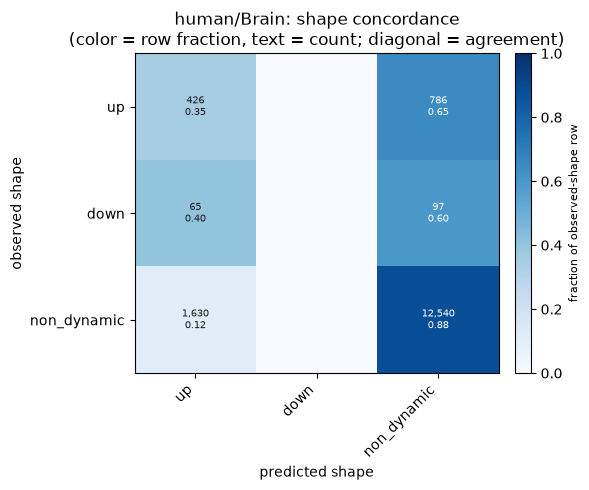

In [8]:
def plot_shape_concordance(dsub, species, tissue, out_directory, save=True):
    """Section 3 diagnostic: observed-vs-predicted shape concordance matrix for one
    species/tissue's prediction-cluster table."""
    shapes = [s for s in SHAPE_ORDER if s in set(dsub["obs_shape"]) | set(dsub["pred_shape"])]
    ct = pd.crosstab(dsub["obs_shape"], dsub["pred_shape"]).reindex(index=shapes, columns=shapes, fill_value=0)
    frac_rows = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0)

    fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(shapes) + 3), max(5, 0.55 * len(shapes) + 2)))
    im = ax.imshow(frac_rows.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(shapes))); ax.set_xticklabels(shapes, rotation=45, ha="right")
    ax.set_yticks(range(len(shapes))); ax.set_yticklabels(shapes)
    ax.set_xlabel("predicted shape"); ax.set_ylabel("observed shape")
    ax.set_title(f"{species}/{tissue}: shape concordance\n(color = row fraction, text = count; diagonal = agreement)")
    for i in range(len(shapes)):
        for j in range(len(shapes)):
            f = frac_rows.iloc[i, j]
            if ct.iloc[i, j]:
                ax.text(j, i, f"{int(ct.iloc[i, j]):,}\n{f:.2f}" if np.isfinite(f) else f"{int(ct.iloc[i, j]):,}",
                        ha="center", va="center", fontsize=7,
                        color="white" if (np.isfinite(f) and f > 0.5) else "#1a1a1a")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("fraction of observed-shape row", fontsize=8)
    plt.tight_layout()
    if save:
        fig.savefig(os.path.join(out_directory, f"{prefix(species, tissue)}_shape_concordance.png"),
                    dpi=200, bbox_inches="tight")
    plt.show()

plot_shape_concordance(df, SPECIES, TISSUE, OUT_DIR)

## 4 — Per-shape agreement and effect of coverage / centroid distance

Single walk-through example (`SPECIES`/`TISSUE`). **Section 8** repeats this diagnostic for every
species × tissue combination.

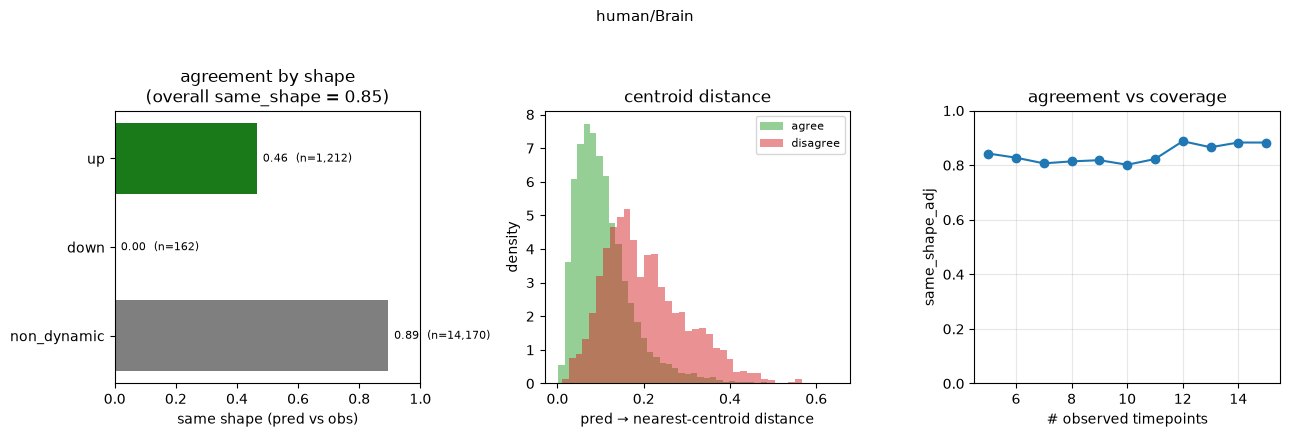

In [9]:
def plot_agreement_breakdown(dsub, species, tissue, out_directory, save=True):
    """Section 4 diagnostic: per-shape agreement, centroid-distance separation, and
    agreement vs. coverage -- for one species/tissue's prediction-cluster table. Uses
    `same_shape_adj` (RMSE-adjusted, see the note above Section 5), not raw `same_shape`.
    No separate "broad" panel anymore: with the hierarchical dynamic/direction
    scheme (5 labels total), obs_shape is already at that granularity."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

    # (a) per observed category agreement
    by_shape = (dsub.groupby("obs_shape")["same_shape_adj"].agg(["mean", "size"])
                  .reindex(SHAPE_ORDER).dropna())
    ax = axes[0]
    ax.barh(range(len(by_shape)), by_shape["mean"],
            color=[SHAPE_COLORS[s] for s in by_shape.index])
    ax.set_yticks(range(len(by_shape))); ax.set_yticklabels(by_shape.index)
    ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel("same shape (pred vs obs)")
    ax.set_title(f"agreement by shape\n(overall same_shape = {dsub['same_shape_adj'].mean():.2f})")
    for i, (m, n) in enumerate(zip(by_shape["mean"], by_shape["size"])):
        ax.text(min(m + 0.02, 0.98), i, f"{m:.2f}  (n={int(n):,})", va="center", fontsize=8)

    # (b) predicted-centroid distance, agree vs disagree
    ax = axes[1]
    for lab, sub, c in [("agree", dsub[dsub["same_shape_adj"]], "#2ca02c"),
                        ("disagree", dsub[~dsub["same_shape_adj"]], "#d62728")]:
        ax.hist(sub["pred_centroid_dist"], bins=40, alpha=0.5, label=lab, color=c, density=True)
    ax.set_xlabel("pred → nearest-centroid distance"); ax.set_ylabel("density")
    ax.set_title("centroid distance"); ax.legend(fontsize=8)

    # (c) agreement vs observed timepoints
    ax = axes[2]
    g = dsub.groupby("n_obs")["same_shape_adj"].mean()
    ax.plot(g.index, g.values, "o-", color="#1f77b4")
    ax.set_xlabel("# observed timepoints"); ax.set_ylabel("same_shape_adj"); ax.set_ylim(0, 1)
    ax.set_title("agreement vs coverage"); ax.grid(alpha=0.3)

    fig.suptitle(f"{species}/{tissue}", fontsize=11, y=1.03)
    plt.tight_layout()
    if save:
        fig.savefig(os.path.join(out_directory, f"{prefix(species, tissue)}_agreement_breakdown.png"),
                    dpi=200, bbox_inches="tight")
    plt.show()
    return dsub

df = plot_agreement_breakdown(df, SPECIES, TISSUE, OUT_DIR)

## 5 — Examples by shape category: correct vs incorrect predictions

For each of the 5 shape labels (`SHAPE_ORDER`), a few observed sites classified into that
shape, split into **correct** and **incorrect** predictions. True/pred line colors reuse
`SHAPE_COLORS` (keyed by each trajectory's own obs/pred label, so matching colors = correct at
a glance); the axis border reuses the agree = green / disagree = red code from Section 4. Each
panel's title also shows that site's own RMSE (Section 2b) — the per-site counterpart of
`amplitude_r2`/`trajectory_r2`, which are only defined pooled across many sites.

**"Correct" here is `pred_shape == obs_shape` OR `site_rmse < EXC_FLOOR`** (0.10), not just the
raw shape match. `classify_dynamic_direction`'s dynamic-or-not gate is a hard, un-buffered
threshold on excursion size with no margin — a prediction that tracks the true trajectory
closely pointwise can still land on the wrong side of it (e.g. `non_dynamic` vs `up`) purely
because its smoothed excursion sits just below 0.10 instead of just above. That's a boundary
artifact, not a real directional miss, and RMSE (which integrates every timepoint, not just the
excursion) stays low for these — so counting them separately as "incorrect" conflated the two
very different failure modes. Sites pulled into "correct" this way despite `same_shape == False`
are flagged **"(rescued)"** in their panel title, so they're still visible as a distinct case.

In [10]:
# Raw SSE_true / SSE_pred trajectory lookup for the walk-through SPECIES/TISSUE, used by the
# example plots below. Cached lazily (on first call) so it works regardless of which order
# downstream cells get run in, without eagerly reloading the (large) predicted-usage parquet.
_traj_cache = {}

def _traj(chrom, pos):
    key = (SPECIES, TISSUE)
    if key not in _traj_cache:
        p = pd.read_parquet(preds_parquet_path(SPECIES),
                            columns=["Chromosome", "Position", "Tissue", "Timepoint",
                                     "SSE_true", "SSE_pred"])
        p = p[p["Tissue"] == TISSUE].copy()
        p["Chromosome"] = p["Chromosome"].astype(str)
        _traj_cache[key] = p
    p = _traj_cache[key]
    s = p[(p["Chromosome"] == str(chrom)) & (p["Position"] == int(pos))].sort_values("Timepoint")
    return s["Timepoint"].to_numpy(), s["SSE_true"].to_numpy(), s["SSE_pred"].to_numpy()

In [11]:
def show_examples_by_category(data, cat_col, obs_col, pred_col, same_col, colors, order,
                              species, tissue, n=4, seed=0, rmse_threshold=EXC_FLOOR):
    """One figure per category in `order` (skipping empty ones): top row = correctly
    predicted examples, bottom row = incorrect. "Correct" here is `same_col` OR
    `site_rmse < rmse_threshold`: a categorical mismatch (e.g. `non_dynamic` vs `up`) whose
    predicted trajectory tracks the true one closely pointwise is a borderline call at the
    exc5 excursion threshold, not a genuine directional miss (see Section 5's note above), so
    it's counted as correct here even though `same_col` is False -- flagged "(rescued)" in the
    title so it's still visible which ones these are. Requires `data["site_rmse"]` (added in
    the cell above). Line colors reuse `colors` (``SHAPE_COLORS``), keyed per-row by that
    trajectory's own obs/pred label; axis borders reuse the agree=green / disagree=red code
    from Section 4."""
    adj_correct = data[same_col] | (data["site_rmse"] < rmse_threshold)
    for cat in order:
        sub = data[data[cat_col] == cat]
        if sub.empty:
            continue
        sub_correct = adj_correct.loc[sub.index]
        correct   = sub[sub_correct].sample(frac=1, random_state=seed)
        incorrect = sub[~sub_correct].sample(frac=1, random_state=seed)
        ncol = max(1, min(n, max(len(correct), len(incorrect))))
        fig, axes = plt.subplots(2, ncol, figsize=(ncol * 4, 6), squeeze=False)
        for row, (label, group) in enumerate(
            [("correct", correct), ("incorrect", incorrect)]
        ):
            for j in range(ncol):
                ax = axes[row, j]
                if j >= len(group):
                    ax.set_visible(False); continue
                r = group.iloc[j]
                t, yt, yp = _traj(r["Chromosome"], r["Position"])
                site_rmse = r["site_rmse"]
                oc = colors.get(r[obs_col], "#333333")
                pc = colors.get(r[pred_col], "#333333")
                ax.plot(t, yt, "-o", ms=3, color=oc, lw=2, label="true")
                ax.plot(t, yp, "--x", ms=4, color=pc, lw=2, label="pred")
                ax.set_ylim(-0.05, 1.05); ax.set_xlim(0.5, 15.5)
                rescued = (not r[same_col]) and site_rmse < rmse_threshold
                title_tag = "  (rescued)" if rescued else ""
                ax.set_title(f"{r['Chromosome']}:{r['Position']}\n"
                             f"obs={r[obs_col]} / pred={r[pred_col]}\n"
                             f"RMSE={site_rmse:.3f}{title_tag}", fontsize=7)
                ax.grid(alpha=0.3)
            axes[row, 0].set_ylabel(f"{label}\nSSE", fontsize=8)
        if len(correct):
            axes[0, 0].legend(fontsize=6, loc="best")
        badge = colors.get(cat, "#7f7f7f")
        fig.suptitle(f"{species}/{tissue}  |  {cat_col}={cat}  "
                    f"(n={len(sub):,}, correct={len(correct):,}, incorrect={len(incorrect):,})",
                    fontsize=10, color=badge, fontweight="bold")
        plt.tight_layout()
        plt.show()

Examples for trajectory shapes:

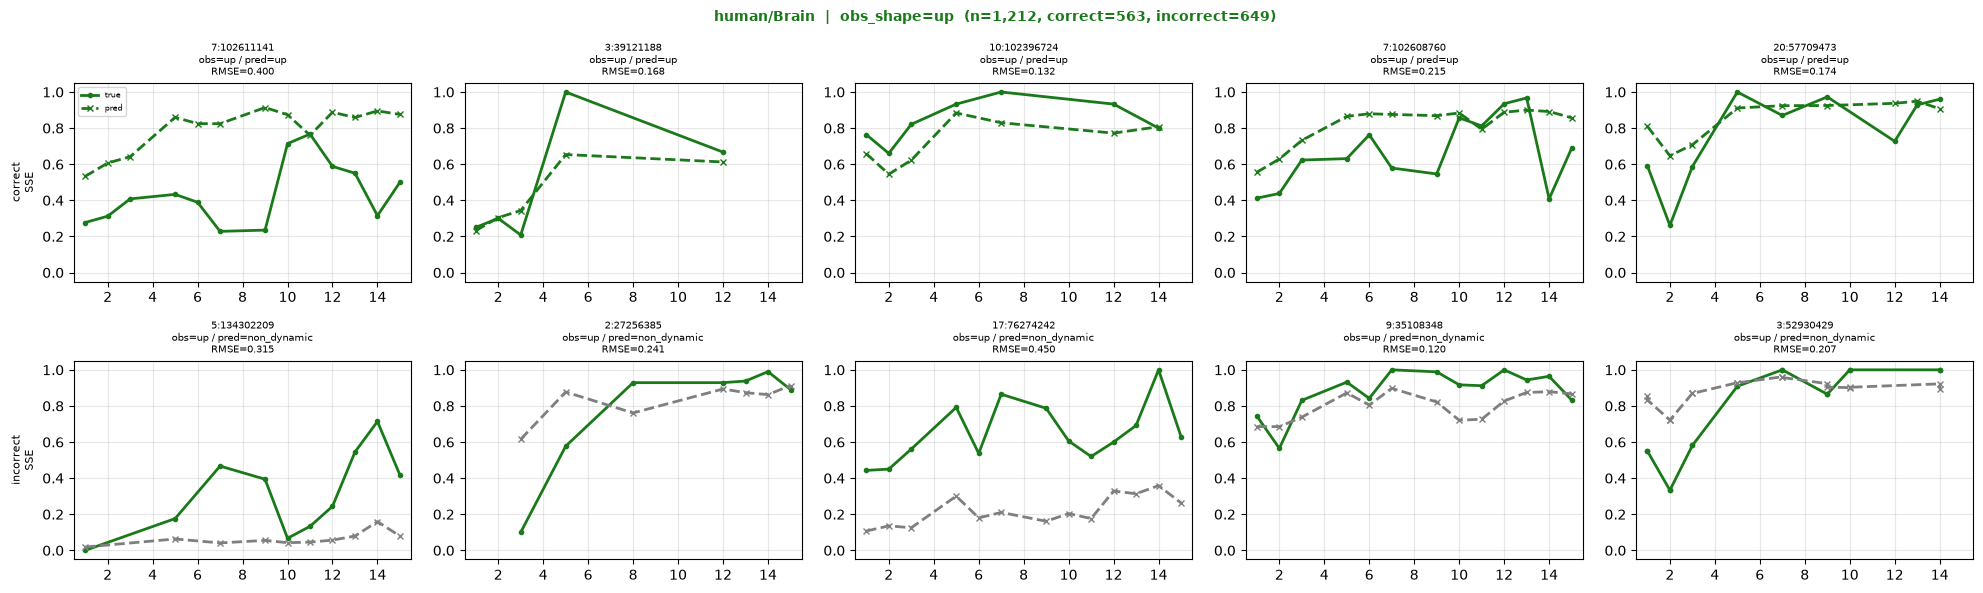

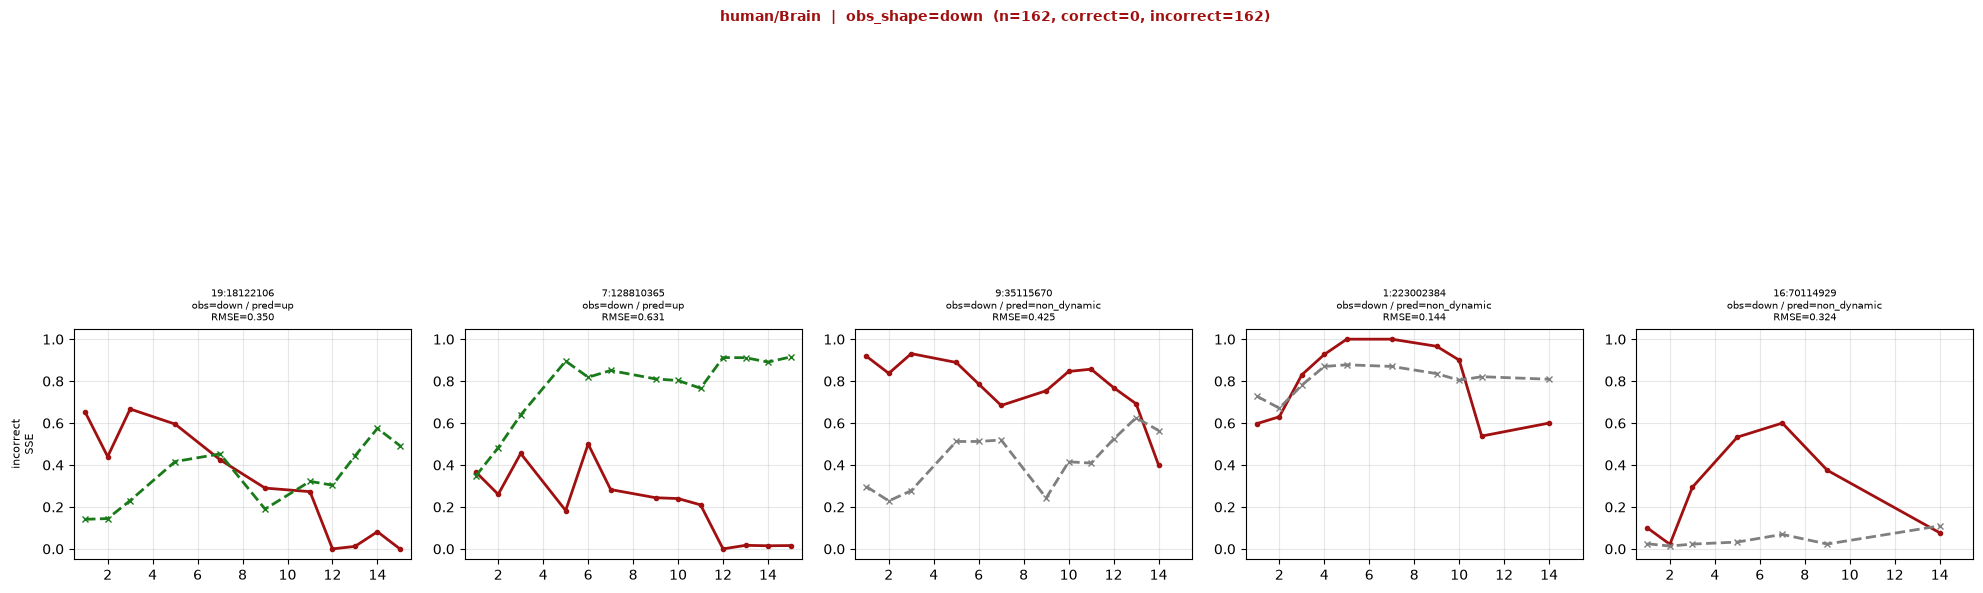

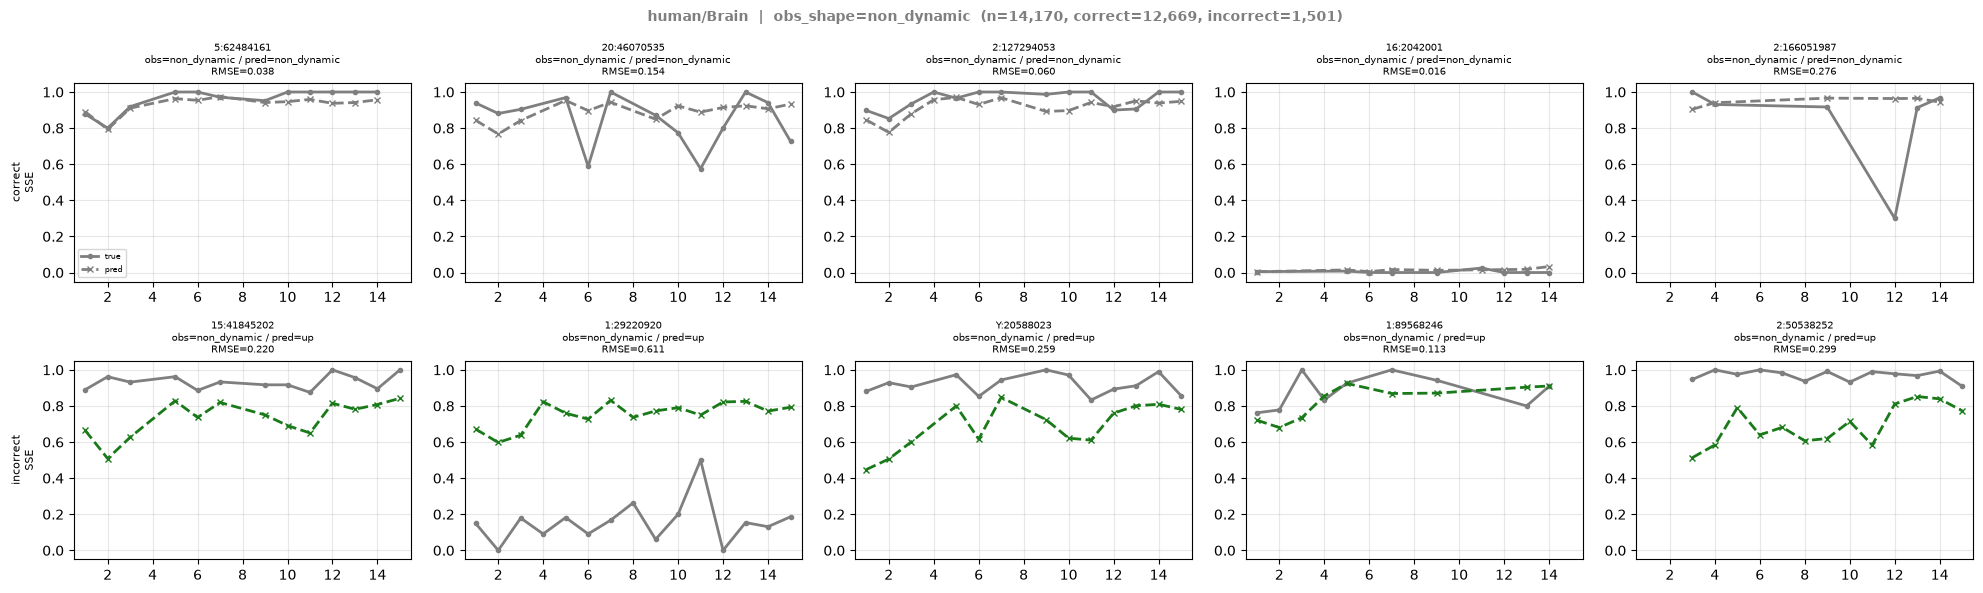

In [12]:
show_examples_by_category(df, "obs_shape", "obs_shape", "pred_shape", "same_shape",
                          SHAPE_COLORS, SHAPE_ORDER, SPECIES, TISSUE, n=5)

## 8 — Diagnostics for every species × tissue

Re-runs the Section 3 (shape concordance) and Section 4 (per-shape agreement, coverage,
centroid distance) diagnostics for **every** `(species, tissue)` combination in `SPECIES_LIST ×
TISSUE_LIST` that has a prediction-cluster parquet — not just the single walk-through example
above. Figures are saved into each combination's own output directory, using the same
`<prefix>_shape_concordance.png` / `<prefix>_agreement_breakdown.png` naming as the single-example
runs.

8 species x tissue combination(s) with prediction-cluster parquets:
  human/Brain
  human/Cerebellum
  human/Liver
  human/Testis
  mouse/Brain
  mouse/Cerebellum
  mouse/Liver
  mouse/Testis

=== human/Brain  (15,544 sites) ===


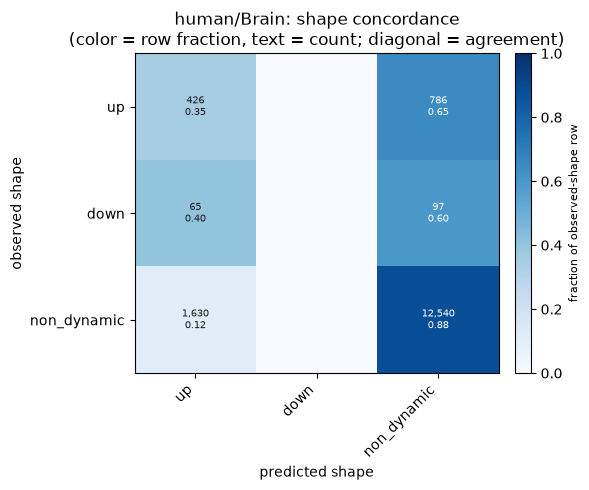

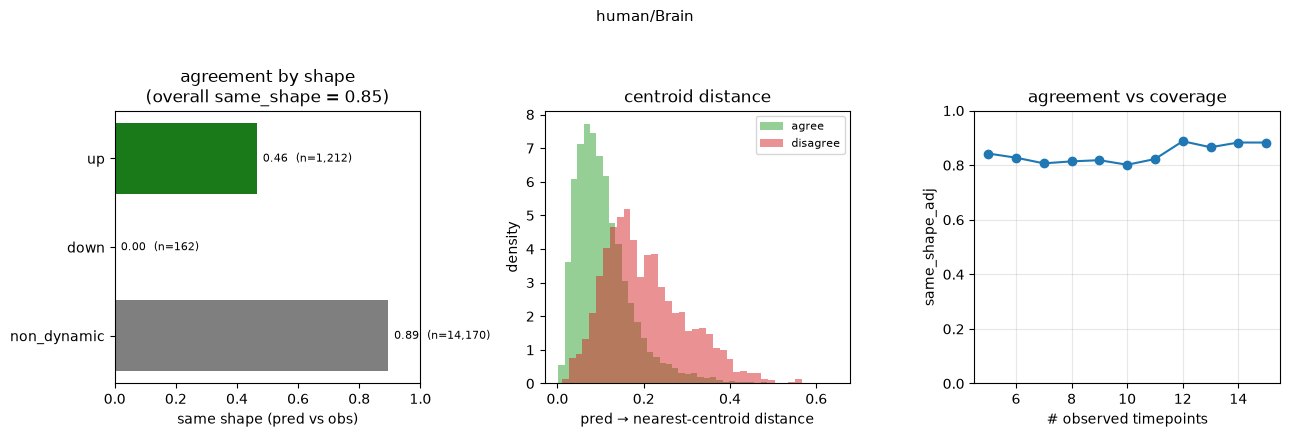


=== human/Cerebellum  (13,391 sites) ===


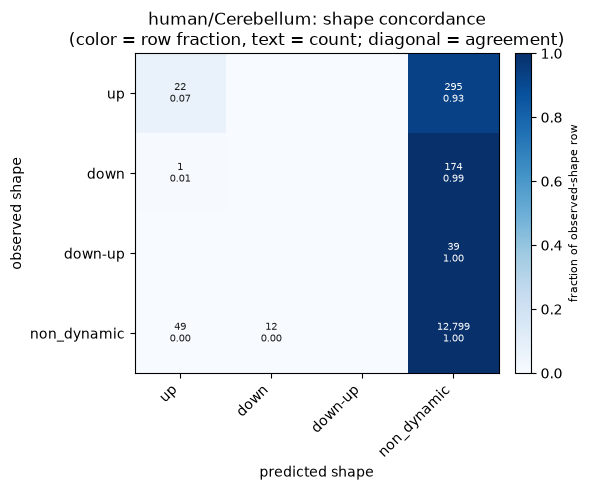

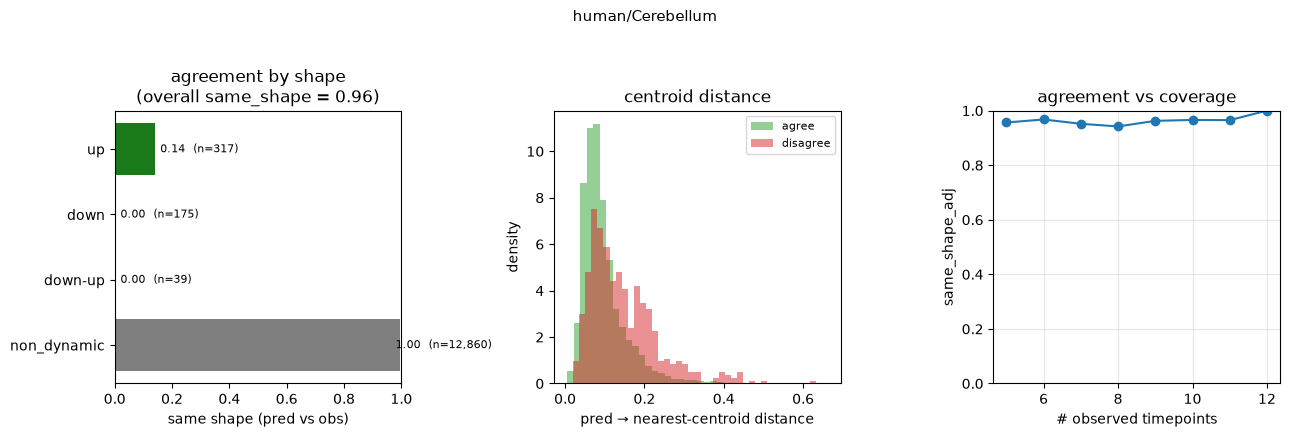


=== human/Liver  (10,177 sites) ===


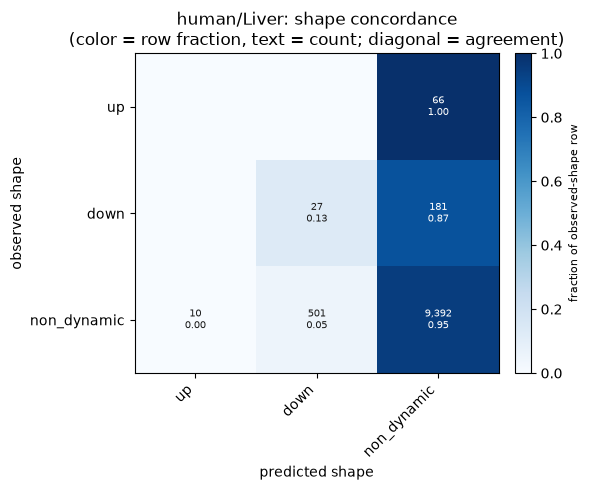

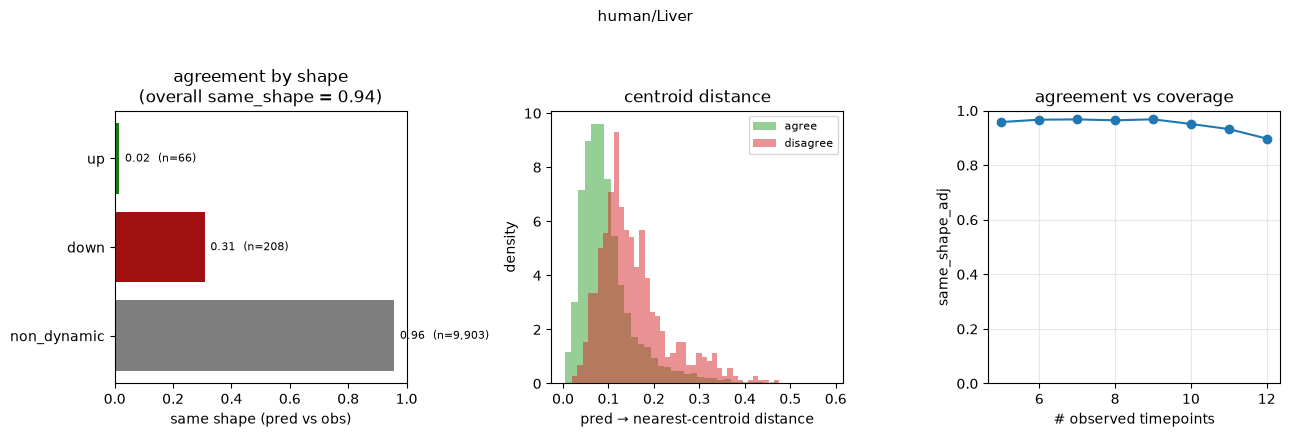


=== human/Testis  (16,008 sites) ===


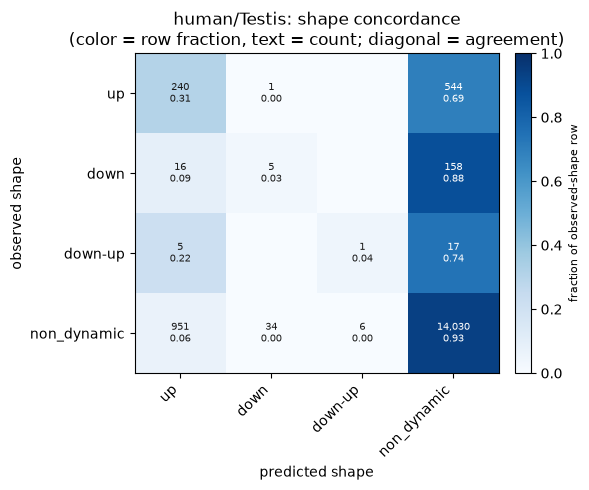

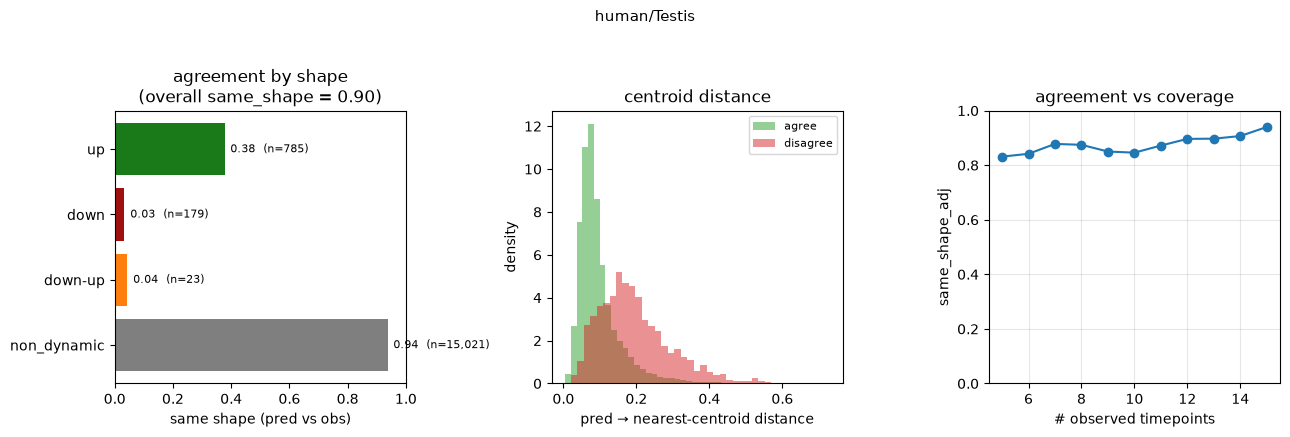


=== mouse/Brain  (11,086 sites) ===


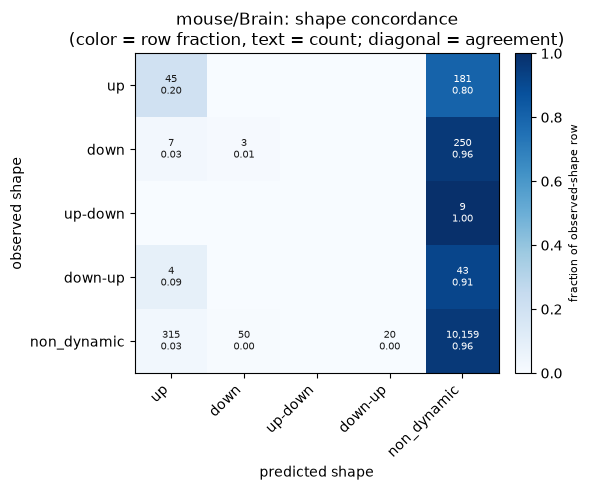

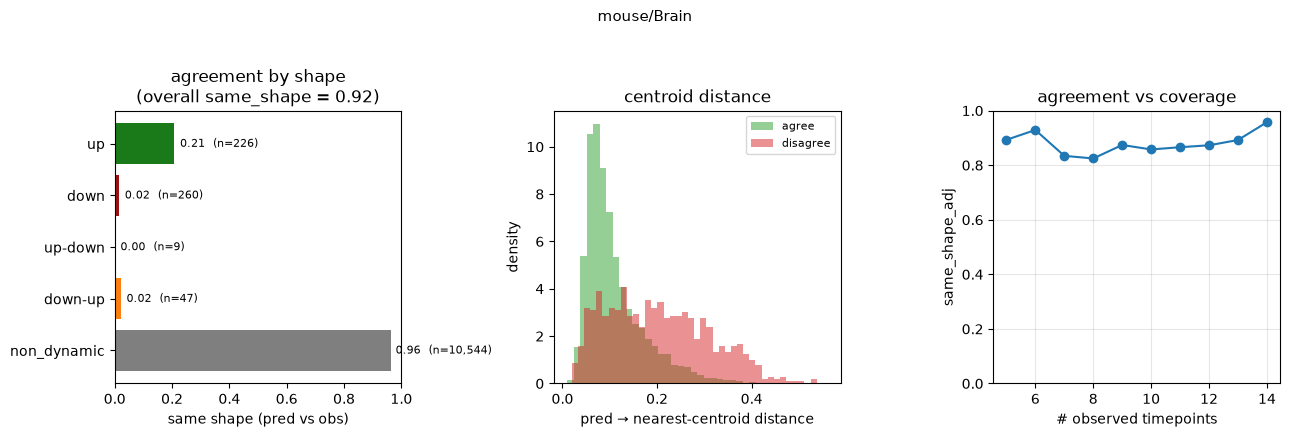


=== mouse/Cerebellum  (11,151 sites) ===


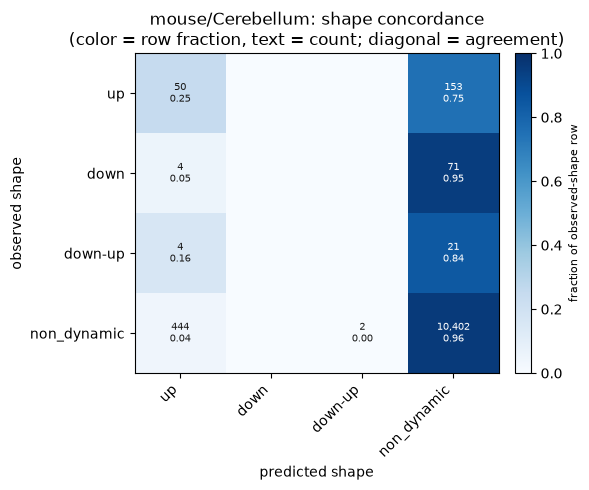

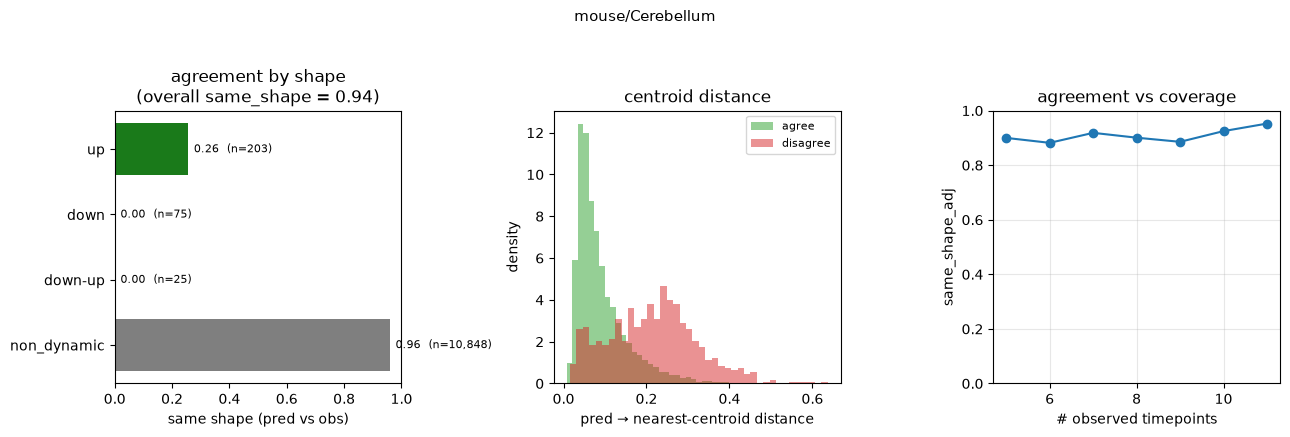


=== mouse/Liver  (9,254 sites) ===


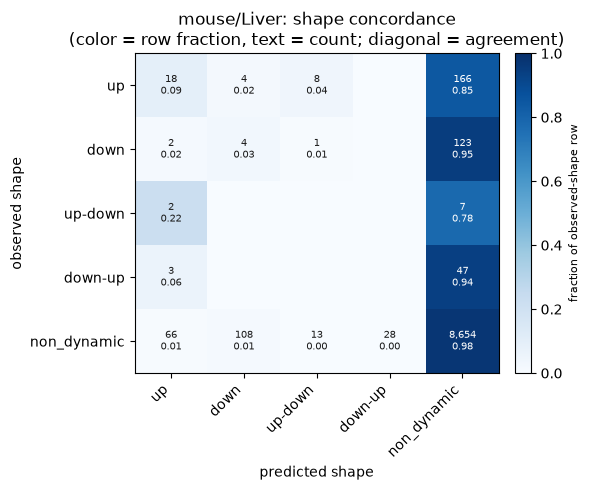

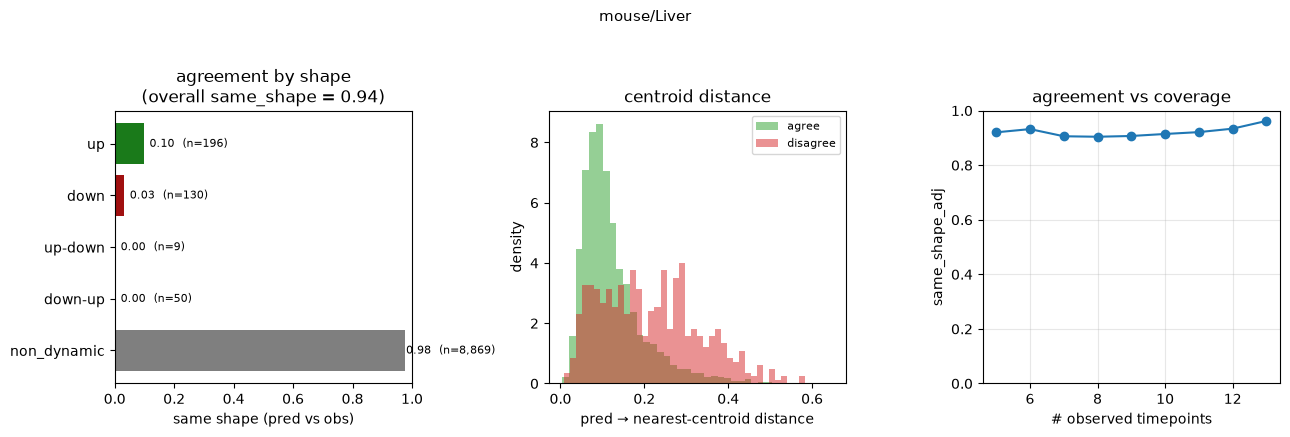


=== mouse/Testis  (10,950 sites) ===


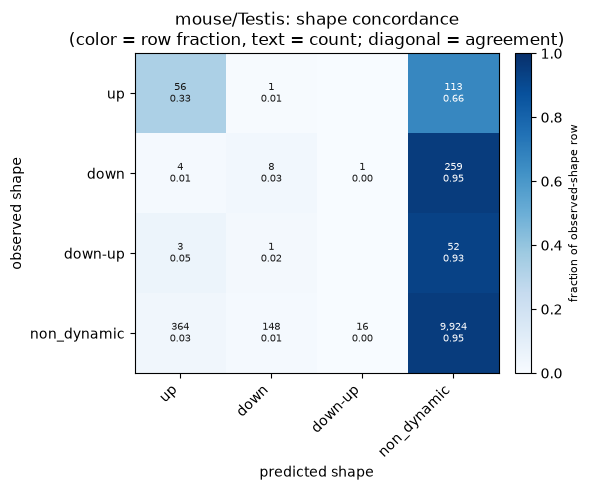

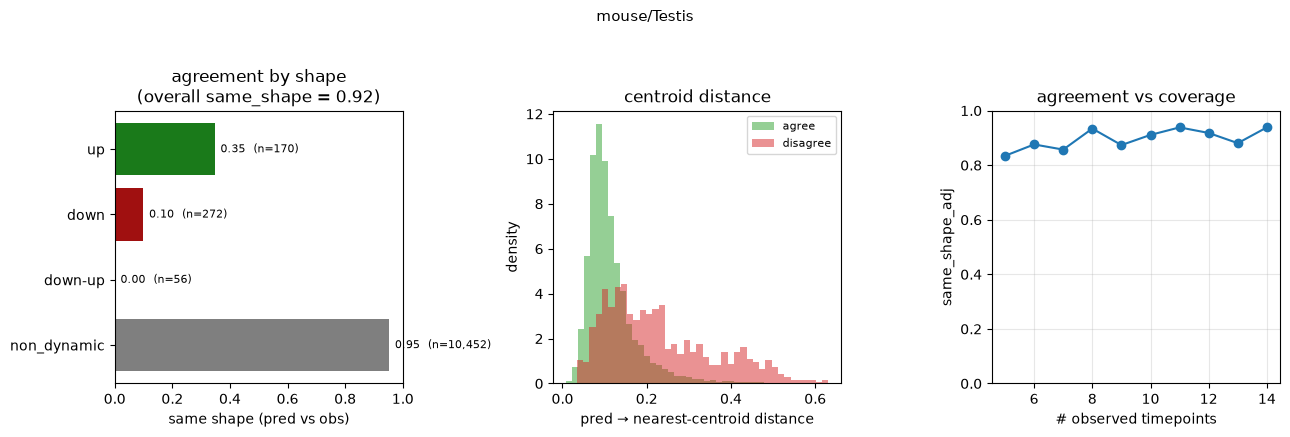

n_sites  shape_pred_vs_obs  shape_obs_vs_ref
species tissue                                                  
human   Brain         15544              0.851             0.942
        Cerebellum    13391              0.959             0.968
        Liver         10177              0.938             0.979
        Testis        16008              0.898             0.965
mouse   Brain         11086              0.921             0.966
        Cerebellum    11151              0.938             0.979
        Liver          9254              0.938             0.964
        Testis        10950              0.917             0.978

In [13]:
combos = [(sp, tis) for sp in SPECIES_LIST for tis in TISSUE_LIST
          if os.path.exists(pred_clusters_path(sp, tis))]
print(f"{len(combos)} species x tissue combination(s) with prediction-cluster parquets:")
for sp, tis in combos:
    print(f"  {sp}/{tis}")

all_diag_rows = []
for sp, tis in combos:
    d = load_annotated(sp, tis)
    o = out_dir(sp, tis)
    print(f"\n=== {sp}/{tis}  ({len(d):,} sites) ===")
    plot_shape_concordance(d, sp, tis, o)
    plot_agreement_breakdown(d, sp, tis, o)
    all_diag_rows.append(dict(
        species=sp, tissue=tis, n_sites=len(d),
        shape_pred_vs_obs=round(d["same_shape_adj"].mean(), 3),
        shape_obs_vs_ref=round((d["obs_shape"] == d["ref_shape"]).mean(), 3),
    ))

all_diag_summary = pd.DataFrame(all_diag_rows).set_index(["species", "tissue"])
display(all_diag_summary)

In [14]:
# Trajectory magnitude (amplitude_r2 + rmse, see Section 2b) for every species x tissue
# combination, reusing `combos` from the diagnostics loop above.
magnitude_rows = []
for sp, tis in combos:
    d = pd.read_parquet(pred_clusters_path(sp, tis))
    m = compute_magnitude_metrics(sp, tis, sites=list(zip(d["Chromosome"], d["Position"])))
    magnitude_rows.append(dict(species=sp, tissue=tis, **m))

magnitude_summary = pd.DataFrame(magnitude_rows).set_index(["species", "tissue"]).round(3)
display(magnitude_summary)

n_sites_total  n_sites_eligible   rmse  amplitude_r2  \
species tissue                                                             
human   Brain               15541              4468  0.266        -0.813   
        Cerebellum          13390              2623  0.284        -0.805   
        Liver               10177              1785  0.253        -2.040   
        Testis              16004              3056  0.278        -1.073   
mouse   Brain               10886              1987  0.277        -0.966   
        Cerebellum          11041              1493  0.310        -1.068   
        Liver                9145              1593  0.275        -0.982   
        Testis              10812              2079  0.279        -0.941   

                    trajectory_r2  
species tissue                     
human   Brain              -1.917  
        Cerebellum         -2.367  
        Liver              -2.782  
        Testis             -2.174  
mouse   Brain              -1.819  
        Cerebellum         -2.574  
        Liver              -2.129  
        Testis             -2.049

## 9 — Agreement by shape: species × tissue overview

Two heatmaps, same layout: **x-axis = species × tissue** (grouped by species), **y-axis =
shape** (shared, `SHAPE_ORDER`).

- **Shape agreement** — cell color = per-shape RMSE-adjusted `same_shape` agreement
  (`same_shape_adj`, see the note above Section 5), red (disagree) → green (agree) — reusing
  the agree/disagree color code from Sections 4-5.
- **RMSE** — cell color = per-shape mean `site_rmse` (Section 2b), green (low/good) → red
  (high/bad); lower is better here, unlike the agreement heatmap above.

Lets you spot at a glance which shapes are hardest to predict, and whether that's consistent
across species/tissues or specific to a few — and whether shape and RMSE difficulty line up.

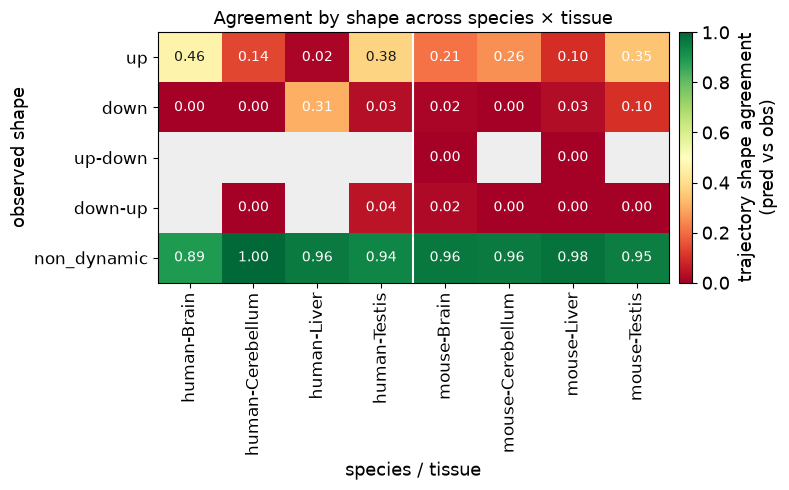

In [15]:
def plot_agreement_by_shape_heatmap(species_list, tissue_list, split=SPLIT, save=True):
    """Section 9: single heatmap, x = species x tissue (grouped by species),
    y = shape (shared, SHAPE_ORDER). Reuses the agree=green / disagree=red code."""
    combos = [(sp, tis) for sp in species_list for tis in tissue_list]
    mat = np.full((len(SHAPE_ORDER), len(combos)), np.nan)
    labels = []
    for c, (sp, tis) in enumerate(combos):
        labels.append(f"{sp}-{tis}")
        path = pred_clusters_path(sp, tis, split)
        if not os.path.exists(path):
            continue
        d = load_annotated(sp, tis, split)
        by_shape = d.groupby("obs_shape")["same_shape_adj"].mean().reindex(SHAPE_ORDER)
        mat[:, c] = by_shape.to_numpy()

    cmap = plt.get_cmap("RdYlGn").copy()
    cmap.set_bad("#eeeeee")
    masked = np.ma.masked_invalid(mat)

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=1, aspect="auto")

    ax.set_yticks(range(len(SHAPE_ORDER)))
    ax.set_yticklabels(SHAPE_ORDER, fontsize=12)
    ax.set_xticks(range(len(combos)))
    ax.set_xticklabels(labels, fontsize=12, rotation=90, ha="center")

    for r in range(len(SHAPE_ORDER)):
        for c in range(len(combos)):
            v = mat[r, c]
            if np.isfinite(v):
                ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=10,
                        color="white" if (v < 0.35 or v > 0.65) else "#1a1a1a")

    for c in range(len(tissue_list), len(combos), len(tissue_list)):
        ax.axvline(c - 0.5, color="white", lw=1.5)

    ax.set_xlabel("species / tissue", fontsize=13); ax.set_ylabel("observed shape", fontsize=13)
    ax.set_title("Agreement by shape across species × tissue", fontsize=13)
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("trajectory shape agreement\n(pred vs obs)", fontsize=13)
    cbar.ax.tick_params(labelsize=13)
    plt.tight_layout()
    if save:
        fig.savefig(os.path.join(REF_DIR, "agreement_by_shape_species_tissue_heatmap.png"),
                    dpi=600, bbox_inches="tight")
    plt.show()

plot_agreement_by_shape_heatmap(SPECIES_LIST, TISSUE_LIST)

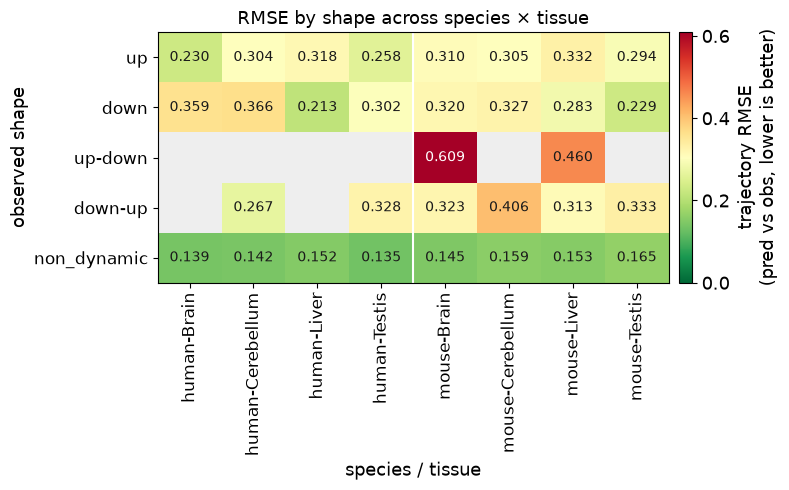

In [16]:
def plot_rmse_by_shape_heatmap(species_list, tissue_list, split=SPLIT, save=True):
    """Section 9: RMSE counterpart of `plot_agreement_by_shape_heatmap` -- same layout
    (x = species x tissue grouped by species, y = shape, shared SHAPE_ORDER), but cell color
    is per-shape mean `site_rmse` (lower is better) instead of `same_shape_adj` (higher is
    better), so it uses a reversed sequential colormap with a data-driven ceiling (RMSE isn't
    bounded to [0, 1] like the agreement fraction)."""
    combos = [(sp, tis) for sp in species_list for tis in tissue_list]
    mat = np.full((len(SHAPE_ORDER), len(combos)), np.nan)
    labels = []
    for c, (sp, tis) in enumerate(combos):
        labels.append(f"{sp}-{tis}")
        path = pred_clusters_path(sp, tis, split)
        if not os.path.exists(path):
            continue
        d = load_annotated(sp, tis, split)
        by_shape = d.groupby("obs_shape")["site_rmse"].mean().reindex(SHAPE_ORDER)
        mat[:, c] = by_shape.to_numpy()

    vmax = float(np.nanmax(mat)) if np.isfinite(mat).any() else 1.0
    cmap = plt.get_cmap("RdYlGn_r").copy()
    cmap.set_bad("#eeeeee")
    masked = np.ma.masked_invalid(mat)

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=vmax, aspect="auto")

    ax.set_yticks(range(len(SHAPE_ORDER)))
    ax.set_yticklabels(SHAPE_ORDER, fontsize=12)
    ax.set_xticks(range(len(combos)))
    ax.set_xticklabels(labels, fontsize=12, rotation=90, ha="center")

    for r in range(len(SHAPE_ORDER)):
        for c in range(len(combos)):
            v = mat[r, c]
            if np.isfinite(v):
                frac = v / vmax if vmax > 0 else 0.0
                ax.text(c, r, f"{v:.3f}", ha="center", va="center", fontsize=10,
                        color="white" if (frac < 0.2 or frac > 0.8) else "#1a1a1a")

    for c in range(len(tissue_list), len(combos), len(tissue_list)):
        ax.axvline(c - 0.5, color="white", lw=1.5)

    ax.set_xlabel("species / tissue", fontsize=13); ax.set_ylabel("observed shape", fontsize=13)
    ax.set_title("RMSE by shape across species × tissue", fontsize=13)
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("trajectory RMSE\n(pred vs obs, lower is better)", fontsize=13)
    cbar.ax.tick_params(labelsize=13)
    plt.tight_layout()
    if save:
        fig.savefig(os.path.join(REF_DIR, "rmse_by_shape_species_tissue_heatmap.png"),
                    dpi=600, bbox_inches="tight")
    plt.show()

plot_rmse_by_shape_heatmap(SPECIES_LIST, TISSUE_LIST)